In [4]:
import sys
print(sys.executable)
!"{sys.executable}" -m pip install rasterstats

c:\Users\sonal\anaconda3\envs\geo_env\python.exe


In [5]:
import geopandas as gpd
import osmnx as ox
import rasterio
import rasterstats
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [6]:
# --- 1. CONFIGURATION ---
place_name = "Kurla, Mumbai, India"  # <-- Use the parent area
dem_path = "kurla.tif"


# --- 2. LOAD OSM VECTOR DATA ---
# Use osmnx to get buildings and rivers
buildings = ox.features_from_place(place_name, tags={'building': True})
print(f"Found {len(buildings)} buildings.")

# Try to get waterways from the place boundary first
rivers = None
for tags in [
    {'waterway': ['river', 'stream', 'canal', 'drain']},
    {'waterway': True},
]:
    try:
        rivers = ox.features_from_place(place_name, tags=tags)
        print(f"Found {len(rivers)} waterway features from place boundary.")
        break
    except Exception:
        continue

# If no waterways in the boundary, fall back to point-based search with larger radius
if rivers is None:
    print("No waterways found in place boundary. Trying point-based search (5km radius)...")
    center_point = ox.geocode(place_name)
    for dist in [5000, 10000]:
        try:
            rivers = ox.features_from_point(center_point, tags={'waterway': True}, dist=dist)
            print(f"Found {len(rivers)} waterway features within {dist}m of center.")
            break
        except Exception:
            continue

if rivers is None or rivers.empty:
    raise Exception("No waterway features found at all. Cannot compute flood vulnerability.")

Found 1 buildings.
No waterways found in place boundary. Trying point-based search (5km radius)...
Found 214 waterway features within 5000m of center.


In [7]:
# --- 2. LOAD OSM VECTOR DATA (BY POINT) ---

# Define a search distance in meters (e.g., 2500m = 2.5km radius)
search_dist = 2500 

print(f"Geocoding '{place_name}' to a point...")
try:
    center_point = ox.geocode(place_name)
except Exception as e:
    print(f"Error geocoding '{place_name}': {e}")
    print("Please try a different or more specific place name.")
    exit()

print(f"Fetching features within {search_dist}m of the point...")

# Get buildings within that distance
buildings = ox.features_from_point(
    center_point=center_point, 
    tags={'building': True}, 
    dist=search_dist
)
print(f"Found {len(buildings)} buildings.")

# Get waterways - try increasing radii until we find some
rivers = None
for dist in [search_dist, 5000, 10000]:
    try:
        rivers = ox.features_from_point(
            center_point=center_point, 
            tags={'waterway': True}, 
            dist=dist
        )
        print(f"Found {len(rivers)} waterway features within {dist}m.")
        break
    except Exception:
        print(f"No waterways found within {dist}m, expanding search...")
        continue

if rivers is None or rivers.empty:
    raise Exception("No waterway features found even at 10km radius. Cannot compute flood vulnerability.")

Geocoding 'Kurla, Mumbai, India' to a point...
Fetching features within 2500m of the point...
Found 6124 buildings.
Found 47 waterway features within 2500m.


In [8]:
# --- 3. LOAD RASTER DATA ---
# Open the DEM file
try:
    with rasterio.open(dem_path) as src_dem:
        dem_array = src_dem.read(1) # Read the first band
        affine = src_dem.transform  # Get the transformation matrix
        dem_crs = src_dem.crs       # Get the CRS
        print(f"\nDEM loaded successfully. CRS: {dem_crs}")
except rasterio.errors.RasterioIOError:
    print(f"Error: Could not find or open {dem_path}.")
    print("Please make sure you've downloaded the DEM and placed it in the correct folder.")
    exit()


DEM loaded successfully. CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


In [9]:
# --- DEBUGGING SCRIPT (REPLACE STEP 3) ---

print("--- STARTING DEBUG ---")

# 1. Check if we actually found buildings and rivers
print(f"Buildings Found: {len(buildings)}")
print(f"Rivers Found: {len(rivers)}")

if rivers.empty:
    print("WARNING: No rivers were found. This might be one source of the error.")
    print("Try relaxing your tags, e.g., tags={'waterway': ['river', 'stream']}")

# 2. Check the bounds and CRS of our vector data
print(f"\nBuildings CRS: {buildings.crs}")
print(f"Buildings Bounds (lon, lat): {buildings.total_bounds}")

# 3. Check the bounds and CRS of our raster DEM
try:
    with rasterio.open(dem_path) as src_dem:
        dem_crs = src_dem.crs
        dem_bounds = src_dem.bounds
        print(f"\nDEM CRS: {dem_crs}")
        print(f"DEM Bounds (left, bottom, right, top): {dem_bounds}")
        
        # 4. Check for Overlap
        # Reproject buildings to DEM's CRS to compare
        try:
            buildings_dem_crs = buildings.to_crs(dem_crs)
            
            # Use GeoPandas to check for spatial intersection
            # We check if *any* building geometry intersects the DEM's bounding box
            from shapely.geometry import box
            dem_bbox = box(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top)
            
            # This will be True if there is any overlap at all
            overlaps = buildings_dem_crs.geometry.intersects(dem_bbox).any()
            
            print(f"\nDo buildings and DEM overlap? {overlaps}")
            
            if not overlaps:
                print("\n*** CRITICAL ERROR ***")
                print("Your building data and your DEM file do not overlap.")
                print("Your building bounds are far away from your DEM bounds.")
                
        except Exception as e:
            print(f"\nError comparing bounds. Are CRSs compatible? {e}")

except rasterio.errors.RasterioIOError:
    print(f"Error: Could not find or open {dem_path}.")
except Exception as e:
    print(f"An error occurred reading the DEM: {e}")

print("\n--- DEBUGGING COMPLETE ---")

--- STARTING DEBUG ---
Buildings Found: 6124
Rivers Found: 47

Buildings CRS: epsg:4326
Buildings Bounds (lon, lat): [72.855432  19.0424711 72.903996  19.0886089]

DEM CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
DEM Bounds (left, bottom, right, top): BoundingBox(left=72.83986111114461, bottom=19.030138888883464, right=72.93986111114462, top=19.120138888883474)

Do buildings and DEM overlap? True

--- DEBUGGING COMPLETE ---


In [10]:
print("Starting feature engineering...")

# --- FEATURE 1: ELEVATION ---
# Reproject buildings to match the DEM's CRS
buildings_dem_crs = buildings.to_crs(dem_crs)

# Calculate zonal stats (get mean elevation for each building polygon)
# This is the magic! It maps the raster pixels to your vector polygons.
elevation_stats = rasterstats.zonal_stats(
    buildings_dem_crs.geometry,
    dem_array,
    affine=affine,
    stats=['mean'],  # You can also get 'min', 'max', 'median'
    nodata=-9999
)

# *** FIX 1: Create the DataFrame WITH the correct index ***
# We pass the index from the GeoDataFrame we used for the stats.
features_df = pd.DataFrame(elevation_stats, index=buildings_dem_crs.index)
features_df.rename(columns={'mean': 'elevation'}, inplace=True)

# --- FEATURE 2: DISTANCE TO RIVER ---
# Project both buildings and rivers to a local UTM for accurate distance
buildings_proj = ox.projection.project_gdf(buildings, to_latlong=False)
rivers_proj = ox.projection.project_gdf(rivers, to_crs=buildings_proj.crs)

# Combine all river segments into one single geometry
all_rivers = rivers_proj.geometry.union_all()

# *** THIS LINE WILL NOW WORK ***
# Both `features_df` and the distance Series share the same OSM index
features_df['dist_to_river'] = buildings_proj.geometry.distance(all_rivers)

# --- CLEAN DATA ---
print("\nCleaning and merging data...")

# Drop any buildings that failed (e.g., were outside the DEM or had no elevation)
features_df.dropna(subset=['elevation', 'dist_to_river'], inplace=True)

# *** FIX 2: Join the features back to the projected GeoDataFrame ***
# We use .join() which is fast and uses the index.
# 'how=inner' automatically drops buildings that didn't have valid features.
buildings_with_features = buildings_proj.join(features_df, how='inner')

if buildings_with_features.empty:
    raise Exception("No buildings with valid features found. Check your DEM coverage.")

print(f"\nFeature engineering complete. {len(buildings_with_features)} buildings processed.")
print(buildings_with_features[['elevation', 'dist_to_river']].head())

Starting feature engineering...

Cleaning and merging data...

Feature engineering complete. 2287 buildings processed.
                    elevation  dist_to_river
element id                                  
node    2238567174       10.0     708.310521
        2319153768       19.0     951.537202
        2319401656        8.0     966.019553
        3135108218       13.0     495.910815
        3204167571        6.0     234.040680


In [11]:
print("\nRunning K-Means clustering...")

# Select only the features for the model
X = buildings_with_features[['elevation', 'dist_to_river']]

# Scale the features (very important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run the K-Means algorithm
kmeans = KMeans(
    n_clusters=3,  # We want 3 clusters: Low, Medium, High risk
    random_state=42,
    n_init=10  # Run it 10 times and pick the best
)
buildings_with_features['cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering complete.")

# --- Analyze the clusters ---
# Let's see what the model found
cluster_analysis = buildings_with_features.groupby('cluster')[['elevation', 'dist_to_river']].mean()
print("\nCluster Analysis (Averages):")
print(cluster_analysis)

# --- INTERPRET YOUR RESULTS ---
# You must do this manually. Look at the output above.
# Example:
#   Cluster 0: Low elevation, Low distance --> HIGH RISK
#   Cluster 1: High elevation, High distance --> LOW RISK
#   Cluster 2: Medium elevation, Medium distance --> MEDIUM RISK

# Create a mapping from cluster ID to a risk label
# !! YOU MUST ADJUST THIS BASED ON YOUR `cluster_analysis` OUTPUT !!
# This is just an example.
sorted_clusters = cluster_analysis.sort_values(by='elevation').index
risk_mapping = {
    sorted_clusters[0]: 'High Risk',  # The cluster with the lowest avg elevation
    sorted_clusters[1]: 'Medium Risk',
    sorted_clusters[2]: 'Low Risk'    # The cluster with the highest avg elevation
}
buildings_with_features['risk_level'] = buildings_with_features['cluster'].map(risk_mapping)

print(f"\nRisk mapping applied: {risk_mapping}")


Running K-Means clustering...
Clustering complete.

Cluster Analysis (Averages):
         elevation  dist_to_river
cluster                          
0         6.626399     199.459391
1        14.206645     790.323477
2        12.908206     299.479341

Risk mapping applied: {np.int32(0): 'High Risk', np.int32(2): 'Medium Risk', np.int32(1): 'Low Risk'}


Generating vulnerability map...

Map saved as 'flood_vulnerability_map.png'


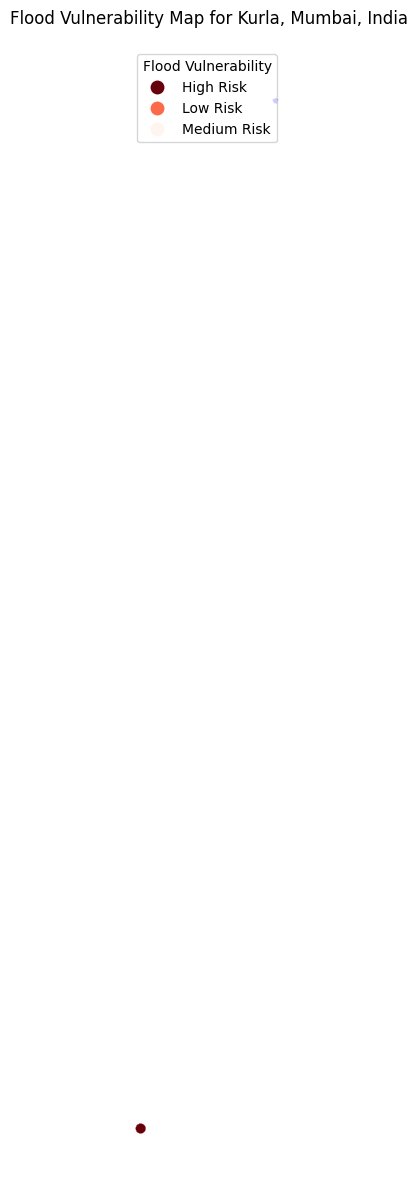

In [13]:
print("Generating vulnerability map...")

fig, ax = plt.subplots(figsize=(12, 12))

# Plot the buildings, colored by their risk level
buildings_with_features.plot(
    ax=ax,
    column='risk_level',
    categorical=True,
    legend=True,
    legend_kwds={'title': "Flood Vulnerability"},
    cmap='Reds_r' # Use a color ramp (e.g., Reds, reversed)
)

# Plot the rivers on top
rivers_proj.plot(ax=ax, color='blue', linewidth=2)

ax.set_title(f"Flood Vulnerability Map for {place_name}")
ax.set_axis_off()
plt.tight_layout()

# Save and show the map
plt.savefig("flood_vulnerability_map.png")
print("\nMap saved as 'flood_vulnerability_map.png'")
plt.show()

In [10]:
import folium

print("\n--- Step 6: Creating Interactive Map ---")

# --- 1. PREPARE DATA FOR FOLIUM ---
buildings_for_map = buildings_with_features.to_crs(epsg=4326)

if buildings_for_map.empty:
    print("ERROR: No building data to map.")
    exit()

# --- 2. FIND THE CENTER OF OUR MAP ---
# *** FIX 1: Changed .unary_union to .union_all() ***
map_center_point = buildings_for_map.geometry.union_all().centroid
map_center = [map_center_point.y, map_center_point.x] # Folium needs (lat, lon)

# Create a base map
m = folium.Map(location=map_center, zoom_start=15, tiles="openstreetmap")

# --- 3. CREATE A COLOR MAPPING ---
color_map = {
    'High Risk': 'red',
    'Medium Risk': 'orange',
    'Low Risk': 'green'
}

# --- 4. CREATE THE STYLE FUNCTION ---
def style_function(feature):
    risk = feature['properties']['risk_level']
    return {
        'fillColor': color_map.get(risk, 'gray'),
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7,
    }

# --- 5. ADD DATA TO THE MAP ---
# *** FIX 2: Changed folium.Tooltip to folium.GeoJsonTooltip ***
folium.GeoJson(
    buildings_for_map,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(  # <-- This is the main fix
        fields=['risk_level', 'elevation', 'dist_to_river'],
        aliases=['Risk Level:', 'Elevation (m):', 'Distance to River (m):'],
        style=("background-color: white; color: black; font-family: arial; "
               "font-size: 12px; padding: 10px;")
    )
).add_to(m)

# Add a layer control to turn layers on/off
folium.LayerControl().add_to(m)

# --- 6. SAVE THE MAP ---
map_filename = 'interactive_flood_map.html'
m.save(map_filename)

print(f"\nSUCCESS! Interactive map saved to: {map_filename}")
print("Just double-click this file to open it in your web browser.")


--- Step 6: Creating Interactive Map ---

SUCCESS! Interactive map saved to: interactive_flood_map.html
Just double-click this file to open it in your web browser.


In [12]:
import geopandas as gpd

print("\n--- Step 7: Exporting to GeoPackage for QGIS ---")

# We'll use the 'buildings_for_map' GeoDataFrame from Step 6
# as it is already in the standard EPSG:4326 (Lat/Lon)
# which is the most compatible format for QGIS.

output_filename = "flood_vulnerability_data.gpkg"

try:
    # Save the GeoDataFrame to a GeoPackage file
    buildings_for_map.to_file(output_filename, driver="GPKG")
    
    print(f"\nSUCCESS! Data exported to: {output_filename}")
    print("You can now drag and drop this file directly into QGIS.")

except Exception as e:
    print(f"\nAn error occurred while exporting: {e}")

# --- (Optional) Alternative: Export to Shapefile ---
# output_shp = "flood_vulnerability_data.shp"
# buildings_for_map.to_file(output_shp, driver="ESRI Shapefile")
# print(f"Also exported to: {output_shp}")
# print("NOTE: Shapefile column names will be truncated (e.g., 'dist_to_river' -> 'dist_to_ri')")
# (This is why GeoPackage is better!)


--- Step 7: Exporting to GeoPackage for QGIS ---

SUCCESS! Data exported to: flood_vulnerability_data.gpkg
You can now drag and drop this file directly into QGIS.


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.5032
k=3, silhouette=0.4070
k=4, silhouette=0.3872
k=5, silhouette=0.3723
k=6, silhouette=0.3412
k=7, silhouette=0.3399


In [13]:
# --- Inspect kurla.tif DEM file ---
import rasterio
import numpy as np

dem_path = "kurla.tif"

with rasterio.open(dem_path) as src:
    print("=== kurla.tif Metadata ===")
    print(f"Driver:        {src.driver}")
    print(f"CRS:           {src.crs}")
    print(f"Dimensions:    {src.width} x {src.height} (width x height)")
    print(f"Bands:         {src.count}")
    print(f"Data type:     {src.dtypes}")
    print(f"NoData value:  {src.nodata}")
    print(f"Transform:     {src.transform}")
    print(f"Bounds:        {src.bounds}")
    print(f"  Left:   {src.bounds.left}")
    print(f"  Bottom: {src.bounds.bottom}")
    print(f"  Right:  {src.bounds.right}")
    print(f"  Top:    {src.bounds.top}")
    print(f"Resolution:    {src.res} (x, y)")

    # Read band data
    for i in range(1, src.count + 1):
        band = src.read(i)
        valid = band[band != src.nodata] if src.nodata is not None else band
        print(f"\n--- Band {i} Statistics ---")
        print(f"  Shape:   {band.shape}")
        print(f"  Min:     {np.nanmin(valid):.4f}")
        print(f"  Max:     {np.nanmax(valid):.4f}")
        print(f"  Mean:    {np.nanmean(valid):.4f}")
        print(f"  Std Dev: {np.nanstd(valid):.4f}")
        if src.nodata is not None:
            nodata_count = np.sum(band == src.nodata)
            print(f"  NoData pixels: {nodata_count} / {band.size} ({nodata_count/band.size*100:.1f}%)")

    # Show tags/metadata if available
    tags = src.tags()
    if tags:
        print("\n--- File Tags ---")
        for k, v in tags.items():
            print(f"  {k}: {v}")

print("\n=== Inspection Complete ===")

=== kurla.tif Metadata ===
Driver:        GTiff
CRS:           GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Dimensions:    360 x 324 (width x height)
Bands:         1
Data type:     ('int16',)
NoData value:  -32768.0
Transform:     | 0.00, 0.00, 72.84|
| 0.00,-0.00, 19.12|
| 0.00, 0.00, 1.00|
Bounds:        BoundingBox(left=72.83986111114461, bottom=19.030138888883464, right=72.93986111114462, top=19.120138888883474)
  Left:   72.83986111114461
  Bottom: 19.030138888883464
  Right:  72.93986111114462
  Top:    19.120138888883474
Resolution:    (0.0002777777777778146, 0.0002777777777778146) (x, y)

--- Band 1 Statistics ---
  Shape:   (324, 360)
  Min:     -26.0000
  Max:     301.0000
  Mean:    15.3998
  Std Dev: 22.5668
  NoData pixels: 0 / 116640 (0.0%)

--- File Tags ---
  AREA_OR_POINT: Area

=== Inspection C

In [17]:
# --- Convert kurla.tif raster to a DataFrame ---
import rasterio
import numpy as np
import pandas as pd

dem_path = "kurla.tif"

with rasterio.open(dem_path) as src:
    band = src.read(1)
    nodata = src.nodata
    transform = src.transform

    # Build arrays of row/col indices
    rows, cols = np.meshgrid(np.arange(band.shape[0]), np.arange(band.shape[1]), indexing='ij')

    # Convert pixel indices to geographic coordinates (lon, lat)
    xs, ys = rasterio.transform.xy(transform, rows.ravel(), cols.ravel())

    df = pd.DataFrame({
        'longitude': xs,
        'latitude':  ys,
        'elevation_m': band.ravel()
    })

    # Remove nodata pixels
    if nodata is not None:
        df = df[df['elevation_m'] != nodata]

    # Remove NaN just in case
    df = df.dropna(subset=['elevation_m']).reset_index(drop=True)

print(f"Total valid pixels: {len(df)}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumn descriptions:")
print("  longitude   - X coordinate (degrees East)")
print("  latitude    - Y coordinate (degrees North)")
print("  elevation_m - Elevation value in metres")
print(f"\nSample rows:")
print(df.head(10))
print(f"\nSummary statistics:")
print(df.describe())
print(df.shape)

Total valid pixels: 116640

DataFrame shape: (116640, 3)

Column descriptions:
  longitude   - X coordinate (degrees East)
  latitude    - Y coordinate (degrees North)
  elevation_m - Elevation value in metres

Sample rows:
   longitude  latitude  elevation_m
0  72.840000     19.12           29
1  72.840278     19.12           30
2  72.840556     19.12           31
3  72.840833     19.12           31
4  72.841111     19.12           29
5  72.841389     19.12           27
6  72.841667     19.12           27
7  72.841944     19.12           28
8  72.842222     19.12           30
9  72.842500     19.12           31

Summary statistics:
           longitude       latitude    elevation_m
count  116640.000000  116640.000000  116640.000000
mean       72.889861      19.075139      15.399777
std         0.028868       0.025981      22.566847
min        72.840000      19.030278     -26.000000
25%        72.864931      19.052708       5.000000
50%        72.889861      19.075139       9.000000
75

In [21]:
# --- Show which region/area the kurla.tif data covers ---
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "geopy", "-q"], check=True)

import rasterio
import numpy as np
import pandas as pd
from geopy.geocoders import Nominatim
import time

dem_path = "kurla.tif"

geolocator = Nominatim(user_agent="kurla_dem_inspector", timeout=10)

with rasterio.open(dem_path) as src:
    b = src.bounds
    w, h = src.width, src.height
    res = src.res
    crs = src.crs
    band = src.read(1)
    nodata = src.nodata

# Key points to reverse-geocode
key_points = {
    "Center":       ((b.top + b.bottom) / 2, (b.left + b.right) / 2),
    "Top-Left":     (b.top,                   b.left),
    "Top-Right":    (b.top,                   b.right),
    "Bottom-Left":  (b.bottom,                b.left),
    "Bottom-Right": (b.bottom,                b.right),
}

print("=== kurla.tif — Region Coverage ===\n")

records = []
for pt_name, (lat, lon) in key_points.items():
    try:
        loc = geolocator.reverse(f"{lat}, {lon}", language="en")
        addr = loc.raw.get("address", {})
        suburb  = addr.get("suburb", addr.get("neighbourhood", ""))
        city    = addr.get("city", addr.get("town", addr.get("county", "")))
        state   = addr.get("state", "")
        country = addr.get("country", "")
        postcode= addr.get("postcode", "")
        records.append({
            "Point":    pt_name,
            "Suburb / Ward": suburb,
            "City":     city,
            "State":    state,
            "Postcode": postcode,
        })
        time.sleep(1)  # Nominatim rate limit
    except Exception as e:
        records.append({"Point": pt_name, "Suburb / Ward": f"Error: {e}",
                        "City": "", "State": "", "Postcode": ""})

region_df = pd.DataFrame(records).set_index("Point")
print(region_df.to_string())

# Unique areas covered
unique_areas = region_df["Suburb / Ward"].dropna().unique()
print(f"\n=== Unique Areas Covered by this DEM ===")
for area in unique_areas:
    if area and not area.startswith("Error"):
        print(f"  • {area}")

# Summary stats
valid_pixels = int(np.sum(band != nodata)) if nodata is not None else band.size
print(f"\n=== File Summary ===")
print(f"  File          : {dem_path}")
print(f"  Dimensions    : {w} x {h} pixels")
print(f"  Resolution    : ~{res[0]*111320:.0f}m x {res[1]*111320:.0f}m per pixel")
print(f"  Valid pixels  : {valid_pixels:,}")
print(f"  Bounding Box  : ({b.left:.4f}°E, {b.bottom:.4f}°N) → ({b.right:.4f}°E, {b.top:.4f}°N)")
print(f"  CRS           : {crs}")

=== kurla.tif — Region Coverage ===

              Suburb / Ward    City        State Postcode
Point                                                    
Center           Kurla West  Mumbai  Maharashtra   400070
Top-Left       Andheri West  Mumbai  Maharashtra   400058
Top-Right     Vikhroli East  Mumbai  Maharashtra   400083
Bottom-Left    Matunga West          Maharashtra   400016
Bottom-Right    Cheeta Camp  Mumbai  Maharashtra   400094

=== Unique Areas Covered by this DEM ===
  • Kurla West
  • Andheri West
  • Vikhroli East
  • Matunga West
  • Cheeta Camp

=== File Summary ===
  File          : kurla.tif
  Dimensions    : 360 x 324 pixels
  Resolution    : ~31m x 31m per pixel
  Valid pixels  : 116,640
  Bounding Box  : (72.8399°E, 19.0301°N) → (72.9399°E, 19.1201°N)
  CRS           : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],A

In [22]:
# --- Elevation by Area Name ---
import rasterio
import numpy as np
import pandas as pd
from geopy.geocoders import Nominatim
import time

dem_path = "kurla.tif"
geolocator = Nominatim(user_agent="kurla_elev_inspector", timeout=10)

with rasterio.open(dem_path) as src:
    band = src.read(1)
    nodata = src.nodata
    transform = src.transform
    b = src.bounds

# Sample a grid of points across the TIF (7x7 = 49 points)
n = 7
lats = np.linspace(b.bottom, b.top, n)
lons = np.linspace(b.left, b.right, n)

records = []
print("Sampling elevation at grid points and reverse geocoding...")
print("(This may take ~1 minute due to Nominatim rate limits)\n")

for lat in lats:
    for lon in lons:
        # Get elevation at this pixel
        row, col = rasterio.transform.rowcol(transform, lon, lat)
        row = int(np.clip(row, 0, band.shape[0] - 1))
        col = int(np.clip(col, 0, band.shape[1] - 1))
        elev = band[row, col]

        if nodata is not None and elev == nodata:
            continue

        # Reverse geocode to get area name
        try:
            loc = geolocator.reverse(f"{lat}, {lon}", language="en")
            addr = loc.raw.get("address", {})
            area = (addr.get("suburb")
                    or addr.get("neighbourhood")
                    or addr.get("quarter")
                    or addr.get("city_district")
                    or addr.get("county")
                    or "Unknown")
            city = addr.get("city", addr.get("town", ""))
        except Exception:
            area, city = "Unknown", ""

        records.append({
            "Area / Suburb": area,
            "City": city,
            "Latitude": round(lat, 5),
            "Longitude": round(lon, 5),
            "Elevation (m)": round(float(elev), 2),
        })
        time.sleep(1)  # Nominatim rate limit: 1 req/sec

df_elev = pd.DataFrame(records)

# --- Summary: average elevation per named area ---
summary = (
    df_elev.groupby("Area / Suburb")["Elevation (m)"]
    .agg(["mean", "min", "max", "count"])
    .rename(columns={"mean": "Avg Elev (m)", "min": "Min Elev (m)",
                     "max": "Max Elev (m)", "count": "Sample Points"})
    .round(2)
    .sort_values("Avg Elev (m)")
)

print("=== Elevation by Area ===")
print(summary.to_string())

print("\n=== Full Sample Data ===")
print(df_elev.sort_values(["Area / Suburb", "Elevation (m)"]).to_string(index=False))

Sampling elevation at grid points and reverse geocoding...
(This may take ~1 minute due to Nominatim rate limits)

=== Elevation by Area ===
                       Avg Elev (m)  Min Elev (m)  Max Elev (m)  Sample Points
Area / Suburb                                                                 
Wadala                        -3.00          -3.0          -3.0              1
Ghatkopar                      1.50           0.0           3.0              2
Mahul                          2.00           2.0           2.0              1
K/E Ward                       2.00          -1.0           5.0              2
N Ward                         4.00           4.0           4.0              1
Mankhurd                       4.00           0.0           9.0              3
Chembur                        4.50           3.0           6.0              2
Bandra Kurla Complex           5.00           5.0           5.0              1
Khar                           5.00           5.0           5.0      

## Step 8: Add More Features (Terrain + Hydrology)
This section adds new engineered features without modifying earlier steps.

- Feature 1 (Terrain): slope and local relief from the DEM
- Feature 2 (Hydrology): distance to major waterways and local waterway density

In [17]:
import os
import numpy as np
import geopandas as gpd
import rasterio

print("\n--- Step 8A: Terrain Features ---")

# Bootstrap DEM inputs if they are not already in memory
if "dem_array" not in globals() or "affine" not in globals():
    if "dem_path" not in globals():
        dem_path = "kurla.tif"
    if not os.path.exists(dem_path):
        raise FileNotFoundError(
            f"DEM file not found at '{dem_path}'. Run earlier cells or place the DEM in this folder."
        )
    with rasterio.open(dem_path) as src_dem:
        dem_array = src_dem.read(1)
        affine = src_dem.transform
        dem_crs = src_dem.crs
    print(f"Loaded DEM from file: {dem_path}")

# Bootstrap buildings_with_features if missing
if "buildings_with_features" not in globals():
    if "buildings_proj" in globals() and "features_df" in globals():
        buildings_with_features = buildings_proj.join(features_df, how="inner")
        print("Rebuilt buildings_with_features from buildings_proj + features_df")
    elif os.path.exists("flood_vulnerability_data.gpkg"):
        buildings_with_features = gpd.read_file("flood_vulnerability_data.gpkg")
        # Terrain sampling requires building geometry in DEM CRS
        if "dem_crs" in globals() and dem_crs is not None:
            buildings_with_features = buildings_with_features.to_crs(dem_crs)
        print("Loaded buildings_with_features from flood_vulnerability_data.gpkg")
    else:
        raise RuntimeError(
            "Missing 'buildings_with_features'. Run Cells 3 to 8 first or keep flood_vulnerability_data.gpkg in this folder."
        )

# Align CRS explicitly before sampling
if "dem_crs" in globals() and dem_crs is not None and buildings_with_features.crs != dem_crs:
    buildings_with_features = buildings_with_features.to_crs(dem_crs)

# Prepare DEM and derive slope grid
dem = np.array(dem_array, dtype=float)
dem[~np.isfinite(dem)] = np.nan
dem[dem <= -9999] = np.nan

cell_x = float(abs(affine.a))
cell_y = float(abs(affine.e))
grad_y, grad_x = np.gradient(dem, cell_y, cell_x)
slope_deg_grid = np.degrees(np.arctan(np.sqrt(grad_x**2 + grad_y**2)))

def sample_raster_at_centroids(raster, gdf, transform):
    points = gdf.geometry.representative_point()
    values = []
    nrows, ncols = raster.shape
    for pt in points:
        if pt is None or pt.is_empty or (not np.isfinite(pt.x)) or (not np.isfinite(pt.y)):
            values.append(np.nan)
            continue
        r, c = rasterio.transform.rowcol(transform, pt.x, pt.y)
        if (not np.isfinite(r)) or (not np.isfinite(c)):
            values.append(np.nan)
            continue
        r = int(r)
        c = int(c)
        if r < 0 or r >= nrows or c < 0 or c >= ncols:
            values.append(np.nan)
            continue
        values.append(raster[r, c])
    return np.array(values, dtype=float)

def sample_local_relief(dem_grid, gdf, transform, radius_px=1):
    points = gdf.geometry.representative_point()
    values = []
    nrows, ncols = dem_grid.shape
    for pt in points:
        if pt is None or pt.is_empty or (not np.isfinite(pt.x)) or (not np.isfinite(pt.y)):
            values.append(np.nan)
            continue
        r, c = rasterio.transform.rowcol(transform, pt.x, pt.y)
        if (not np.isfinite(r)) or (not np.isfinite(c)):
            values.append(np.nan)
            continue
        r = int(r)
        c = int(c)
        if r < 0 or r >= nrows or c < 0 or c >= ncols:
            values.append(np.nan)
            continue
        r0 = max(0, r - radius_px)
        r1 = min(nrows, r + radius_px + 1)
        c0 = max(0, c - radius_px)
        c1 = min(ncols, c + radius_px + 1)
        win = dem_grid[r0:r1, c0:c1]
        values.append(np.nanmax(win) - np.nanmin(win))
    return np.array(values, dtype=float)

buildings_with_features["slope_deg"] = sample_raster_at_centroids(
    slope_deg_grid, buildings_with_features, affine
)
buildings_with_features["local_relief_m"] = sample_local_relief(
    dem, buildings_with_features, affine, radius_px=1
)

print("Terrain features added: slope_deg, local_relief_m")
print(
    buildings_with_features[["slope_deg", "local_relief_m"]]
    .describe()
    .round(3)
)


--- Step 8A: Terrain Features ---
Terrain features added: slope_deg, local_relief_m
       slope_deg  local_relief_m
count   2287.000        2287.000
mean      86.877           4.042
std       16.437           2.126
min        0.000           0.000
25%       89.977           3.000
50%       89.989           4.000
75%       89.992           5.000
max       89.998          19.000


In [18]:
import os

print("\n--- Step 8B: Hydrology Features ---")

if "buildings_with_features" not in globals():
    raise RuntimeError("Missing 'buildings_with_features'. Run Step 8A first.")

# Bootstrap rivers_proj if missing
if "rivers_proj" not in globals():
    if "rivers" in globals() and "buildings_with_features" in globals():
        rivers_proj = rivers.to_crs(buildings_with_features.crs)
        print("Rebuilt rivers_proj from rivers")
    else:
        # Try to fetch waterways quickly if osmnx context is available
        try:
            if "ox" in globals() and "place_name" in globals():
                rivers = ox.features_from_place(place_name, tags={"waterway": True})
                rivers_proj = rivers.to_crs(buildings_with_features.crs)
                print("Fetched rivers using osmnx fallback")
        except Exception:
            pass

if "rivers_proj" in globals() and rivers_proj is not None and not rivers_proj.empty:
    # Ensure metric distance calculations
    metric_crs = buildings_with_features.estimate_utm_crs()
    b_metric = buildings_with_features.to_crs(metric_crs)
    r_metric = rivers_proj.to_crs(metric_crs)

    river_lengths = r_metric.geometry.length
    length_threshold = river_lengths.quantile(0.75)
    major_rivers = r_metric[river_lengths >= length_threshold].copy()

    if major_rivers.empty:
        major_rivers = r_metric.copy()

    major_union = major_rivers.geometry.union_all()
    buildings_with_features["dist_to_major_waterway"] = (
        b_metric.geometry.distance(major_union).values
    )

    buffer_radius_m = 300.0
    circle_area = np.pi * (buffer_radius_m ** 2)
    river_geoms = r_metric.geometry

    if hasattr(river_geoms, "sindex") and river_geoms.sindex is not None:
        sindex = river_geoms.sindex
    else:
        sindex = None

    densities = []
    for geom in b_metric.geometry:
        buf = geom.buffer(buffer_radius_m)
        if sindex is not None:
            candidate_idx = list(sindex.intersection(buf.bounds))
            candidates = river_geoms.iloc[candidate_idx] if candidate_idx else river_geoms.iloc[[]]
        else:
            candidates = river_geoms

        if len(candidates) == 0:
            densities.append(0.0)
            continue

        clipped = candidates.intersection(buf)
        total_len_m = clipped.length.sum()
        densities.append(float(total_len_m / circle_area))

    buildings_with_features["waterway_density_300m"] = densities
else:
    if "dist_to_river" not in buildings_with_features.columns:
        raise RuntimeError(
            "No waterways available and dist_to_river is missing; run Cells 3 to 7 first."
        )
    # Conservative fallback when waterway geometries are unavailable
    buildings_with_features["dist_to_major_waterway"] = buildings_with_features["dist_to_river"]
    buildings_with_features["waterway_density_300m"] = np.nan
    print("rivers_proj unavailable; using dist_to_river fallback for major-waterway distance")

print("Hydrology features added: dist_to_major_waterway, waterway_density_300m")
print(
    buildings_with_features[["dist_to_major_waterway", "waterway_density_300m"]]
    .describe()
    .round(3)
)


--- Step 8B: Hydrology Features ---
Hydrology features added: dist_to_major_waterway, waterway_density_300m
       dist_to_major_waterway  waterway_density_300m
count                2287.000               2287.000
mean                  593.565                  0.001
std                   488.669                  0.001
min                     0.000                  0.000
25%                   218.009                  0.000
50%                   433.056                  0.000
75%                   899.374                  0.002
max                  2393.255                  0.007


## Step 9: Product Enhancements (Feature 7)
Adds filtered risk layers, richer tooltips, and exports a feature report.

In [23]:
import folium

print("\n--- Step 9: Enhanced Outputs ---")

if "buildings_with_features" not in globals():
    raise RuntimeError("Missing 'buildings_with_features'. Run earlier cells first.")

enhanced_columns = [
    "risk_level",
    "elevation",
    "dist_to_river",
    "dist_to_drainage_m",
    "slope_deg",
    "local_relief_m",
    "dist_to_major_waterway",
    "waterway_density_300m",
    "geometry",
]

available_columns = [c for c in enhanced_columns if c in buildings_with_features.columns]
buildings_for_enhanced_map = buildings_with_features[available_columns].to_crs(epsg=4326).copy()

# Export tabular report for downstream analysis
report_columns = [c for c in buildings_for_enhanced_map.columns if c != "geometry"]
buildings_for_enhanced_map[report_columns].to_csv(
    "flood_vulnerability_feature_report.csv", index=False
)

# Build filtered interactive map with one toggle layer per risk class
center_point = buildings_for_enhanced_map.geometry.union_all().centroid
m2 = folium.Map(location=[center_point.y, center_point.x], zoom_start=15, tiles="openstreetmap")

risk_order = ["High Risk", "Medium Risk", "Low Risk"]
risk_colors = {"High Risk": "red", "Medium Risk": "orange", "Low Risk": "green"}

tooltip_fields = [
    c
    for c in [
        "risk_level",
        "elevation",
        "dist_to_river",
        "dist_to_drainage_m",
        "slope_deg",
        "local_relief_m",
        "dist_to_major_waterway",
        "waterway_density_300m",
    ]
    if c in buildings_for_enhanced_map.columns
]
tooltip_aliases = [f"{c}:" for c in tooltip_fields]

for risk in risk_order:
    subset = buildings_for_enhanced_map[buildings_for_enhanced_map["risk_level"] == risk]
    if subset.empty:
        continue

    layer = folium.FeatureGroup(name=risk, show=True)

    folium.GeoJson(
        subset,
        style_function=lambda feature, rc=risk_colors[risk]: {
            "fillColor": rc,
            "color": "black",
            "weight": 0.5,
            "fillOpacity": 0.7,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=tooltip_fields,
            aliases=tooltip_aliases,
            localize=True,
            sticky=False,
            labels=True,
            style="background-color: white; color: black; font-family: arial; font-size: 12px; padding: 8px;",
        ),
    ).add_to(layer)

    layer.add_to(m2)

folium.LayerControl(collapsed=False).add_to(m2)
enhanced_map_filename = "interactive_flood_map_enhanced.html"
m2.save(enhanced_map_filename)

# Optional enriched geospatial export (keeps geometry + new features)
buildings_for_enhanced_map.to_file(
    "flood_vulnerability_data_enhanced.gpkg",
    driver="GPKG",
)

print("Enhanced outputs created successfully:")
print("1) interactive_flood_map_enhanced.html")
print("2) flood_vulnerability_feature_report.csv")
print("3) flood_vulnerability_data_enhanced.gpkg")


--- Step 9: Enhanced Outputs ---
Enhanced outputs created successfully:
1) interactive_flood_map_enhanced.html
2) flood_vulnerability_feature_report.csv
3) flood_vulnerability_data_enhanced.gpkg


## Step 10: Nearest Drainage Feature
Adds a dedicated nearest-drainage distance feature using OSM drainage-like tags.

In [21]:
print("\n--- Step 10: Nearest Drainage Feature ---")

if "buildings_with_features" not in globals():
    raise RuntimeError("Missing 'buildings_with_features'. Run Step 8A first.")

# Ensure metric CRS for accurate distance calculation
metric_crs = buildings_with_features.estimate_utm_crs()
b_metric = buildings_with_features.to_crs(metric_crs)

drainage_gdf = None

# Preferred source: fetch dedicated drainage tags from OSM
if "ox" in globals() and "place_name" in globals():
    try:
        drainage_tags = {"waterway": ["drain", "ditch", "canal"]}
        drainage_gdf = ox.features_from_place(place_name, tags=drainage_tags)
        if drainage_gdf is not None and not drainage_gdf.empty:
            drainage_gdf = drainage_gdf.to_crs(metric_crs)
            print(f"Fetched {len(drainage_gdf)} drainage features from OSM")
    except Exception as e:
        print(f"OSM drainage fetch failed, using fallback: {e}")

# Fallback source: filter already-loaded rivers by waterway type
if (drainage_gdf is None or drainage_gdf.empty) and "rivers_proj" in globals() and rivers_proj is not None and not rivers_proj.empty:
    r_metric = rivers_proj.to_crs(metric_crs)
    if "waterway" in r_metric.columns:
        drainage_mask = r_metric["waterway"].astype(str).str.lower().isin(["drain", "ditch", "canal"])
        drainage_gdf = r_metric[drainage_mask].copy()
        if drainage_gdf.empty:
            drainage_gdf = None
    print("Using rivers_proj fallback for drainage extraction")

if drainage_gdf is None or drainage_gdf.empty:
    print("No drainage-only features found. Setting dist_to_drainage_m = NaN")
    buildings_with_features["dist_to_drainage_m"] = np.nan
else:
    # Keep only line-like geometries and compute nearest distance
    drainage_gdf = drainage_gdf[drainage_gdf.geometry.notnull()].copy()
    drainage_union = drainage_gdf.geometry.union_all()
    buildings_with_features["dist_to_drainage_m"] = b_metric.geometry.distance(drainage_union).values

print("Feature added: dist_to_drainage_m")
print(buildings_with_features[["dist_to_drainage_m"]].describe().round(3))


--- Step 10: Nearest Drainage Feature ---
OSM drainage fetch failed, using fallback: No matching features. Check query location, tags, and log.
Using rivers_proj fallback for drainage extraction
Feature added: dist_to_drainage_m
       dist_to_drainage_m
count            2287.000
mean              344.095
std               257.108
min                 0.000
25%               148.020
50%               285.276
75%               487.454
max              1188.069
